In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

In [2]:
2+3

5

In [3]:
# Read a book, fast!

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]

In [4]:
print(len('dsc 008'))
print(len(little_women_text))
print(len(little_women_chapters))

7
1021563
47


In [ ]:
Table().with_column('Chapters', little_women_chapters)

In [ ]:
little_women_chapters

In [5]:
# Counts of names in the chapters of Little Women

names = ['Amy', 'Beth', 'Jo', 'Laurie', 'Meg']
mentions = {name: np.char.count(little_women_chapters, name) for name in names}

counts = Table().with_columns([
        'Amy', mentions['Amy'],
        'Beth', mentions['Beth'],
        'Jo', mentions['Jo'],
        'Laurie', mentions['Laurie'],
        'Meg', mentions['Meg']
    ])

print(counts)

Amy  | Beth | Jo   | Laurie | Meg
23   | 26   | 44   | 0      | 26
13   | 12   | 21   | 0      | 20
2    | 2    | 62   | 16     | 36
14   | 18   | 34   | 0      | 17
6    | 14   | 55   | 35     | 13
6    | 28   | 13   | 9      | 5
27   | 5    | 9    | 7      | 5
48   | 9    | 71   | 17     | 16
3    | 5    | 21   | 24     | 71
5    | 5    | 12   | 4      | 4
... (37 rows omitted)


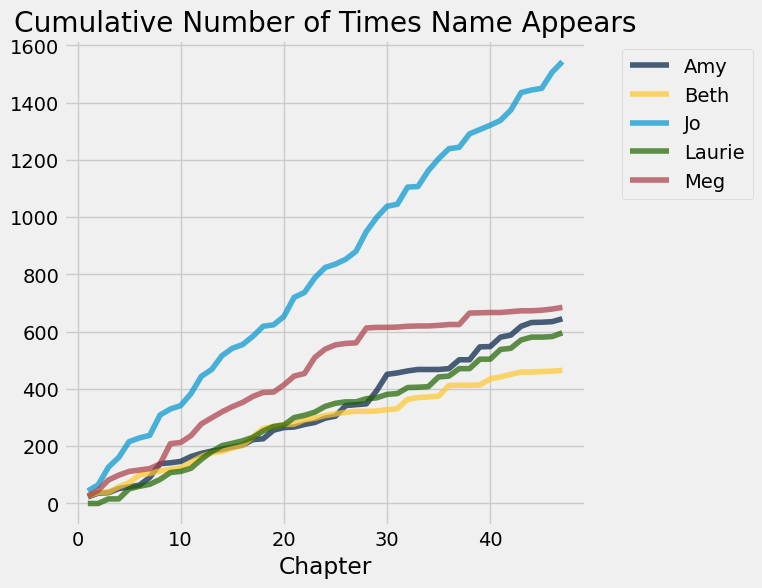

In [6]:
# Plot the cumulative counts

cum_counts = counts.cumsum().with_column('Chapter', np.arange(1, 48, 1))
cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Name Appears');

In [ ]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

length_lw = Table().with_columns([
        'Length', [len(s) for s in little_women_chapters],
        'Periods', np.char.count(little_women_chapters, '.')
    ])

In [ ]:
# The counts for Little Women

length_lw

In [ ]:
plots.figure(figsize=(10,10))
plots.scatter(length_lw[1], length_lw[0], color='darkblue')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');